In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px


In [2]:
sns.set_theme(style="whitegrid")

In [3]:
df = pd.read_csv('Airbnb_Texas_Rentals.csv')

In [4]:
df.head()

,Unnamed: 0,average_rate_per_night,bedrooms_count,city,date_of_listing,description,latitude,longitude,title,url
0,1,$27,2,Humble,May 2016,Welcome to stay in private room with queen bed...,30.020138,-95.293996,2 Private rooms/bathroom 10min from IAH airport,https://www.airbnb.com/rooms/18520444?location...
1,2,$149,4,San Antonio,November 2010,"Stylish, fully remodeled home in upscale NW – ...",29.503068,-98.447688,Unique Location! Alamo Heights - Designer Insp...,https://www.airbnb.com/rooms/17481455?location...
2,3,$59,1,Houston,January 2017,'River house on island close to the city' \nA ...,29.829352,-95.081549,River house near the city,https://www.airbnb.com/rooms/16926307?location...
3,4,$60,1,Bryan,February 2016,Private bedroom in a cute little home situated...,30.637304,-96.337846,Private Room Close to Campus,https://www.airbnb.com/rooms/11839729?location...
4,5,$75,2,Fort Worth,February 2017,Welcome to our original 1920's home. We recent...,32.747097,-97.286434,The Porch,https://www.airbnb.com/rooms/17325114?location...


In [5]:

print("Dataset Dimensions:", df.shape)

df.info()
print("\nStatistical Summary")
df.describe()

Dataset Dimensions: (18259, 10)
<class 'pandas.DataFrame'>
RangeIndex: 18259 entries, 0 to 18258
Data columns (total 10 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              18259 non-null  int64  
 1   average_rate_per_night  18231 non-null  str    
 2   bedrooms_count          18256 non-null  str    
 3   city                    18259 non-null  str    
 4   date_of_listing         18259 non-null  str    
 5   description             18257 non-null  str    
 6   latitude                18225 non-null  float64
 7   longitude               18225 non-null  float64
 8   title                   18256 non-null  str    
 9   url                     18259 non-null  str    
dtypes: float64(2), int64(1), str(7)
memory usage: 1.4 MB

Statistical Summary


,Unnamed: 0,latitude,longitude
count,18259.000000,18225.000000,18225.000000
mean,9130.000000,30.684906,-97.076785
std,5271.063618,1.671008,1.328314
min,1.000000,25.894075,-103.690925
25%,4565.500000,29.693117,-97.817193
50%,9130.000000,30.275907,-97.134467
75%,13694.500000,32.671095,-96.307023
max,18259.000000,35.256299,-93.771139


In [6]:
# Drop the 'Unnamed: 0' column
df = df.drop('Unnamed: 0', axis=1)
print("Remaining Columns:", df.columns.tolist())

Remaining Columns: ['average_rate_per_night', 'bedrooms_count', 'city', 'date_of_listing', 'description', 'latitude', 'longitude', 'title', 'url']


In [7]:
df['average_rate_per_night'] = df['average_rate_per_night'].str.replace('$', '', regex=False).str.replace(',', '', regex=False)

# 2. Convert average_rate_per_night column to numeric
df['average_rate_per_night'] = pd.to_numeric(df['average_rate_per_night'], errors='coerce')

print("New Column Type:", df['average_rate_per_night'].dtype)
print("Number of missing values: ", df['average_rate_per_night'].isnull().sum())

New Column Type: float64
Number of missing values:  28


In [8]:
print("Unique values in bedrooms_count:")
print(df['bedrooms_count'].unique())

print("\nMissing values in bedrooms_count:", df['bedrooms_count'].isnull().sum())

Unique values in bedrooms_count:
<StringArray>
['2', '4', '1', '3', 'Studio', '7', '5', '8', '6', '9', '11', nan, '13', '10']
Length: 14, dtype: str

Missing values in bedrooms_count: 3


In Airbnb Texas property datasets, "studio" in the bedrooms_count column indicates a property where the bedroom, kitchen, and living space are combined into one open area, representing 0 or 0.5 bedrooms rather than a distinct, separate room.

In [9]:
# Replace 'Studio' with 0
df['bedrooms_count'] = df['bedrooms_count'].replace('Studio', '0')

# Convert bedrooms_count column to numeric
df['bedrooms_count'] = pd.to_numeric(df['bedrooms_count'], errors='coerce')

# Dropping rows where price or bedrooms are missing
df.dropna(subset=['average_rate_per_night', 'bedrooms_count'], inplace=True)


print("Final Column Types:")
print(df[['average_rate_per_night', 'bedrooms_count']].dtypes)
print("\nAny remaining missing values in these columns?")
print(df[['average_rate_per_night', 'bedrooms_count']].isnull().sum())
print(f"\nRemaining Rows in Dataset: {len(df)}")

Final Column Types:
average_rate_per_night    float64
bedrooms_count            float64
dtype: object

Any remaining missing values in these columns?
average_rate_per_night    0
bedrooms_count            0
dtype: int64

Remaining Rows in Dataset: 18228


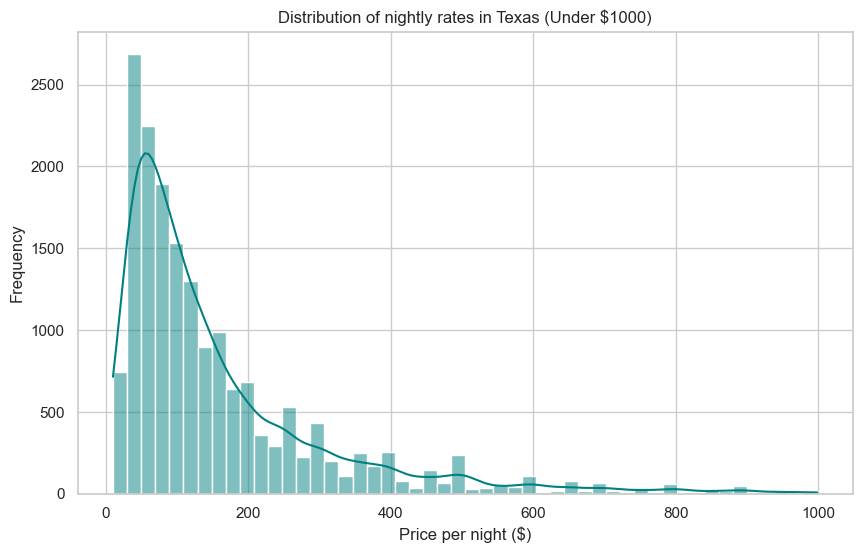

In [10]:
plt.figure(figsize=(10, 6))
# Distribution of priecs under 1000$
sns.histplot(df[df['average_rate_per_night'] < 1000]['average_rate_per_night'], bins=50, kde=True, color='teal')

plt.title('Distribution of nightly rates in Texas (Under $1000)')
plt.xlabel('Price per night ($)')
plt.ylabel('Frequency')
plt.show()

/tmp/ipykernel_10017/2716945726.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')


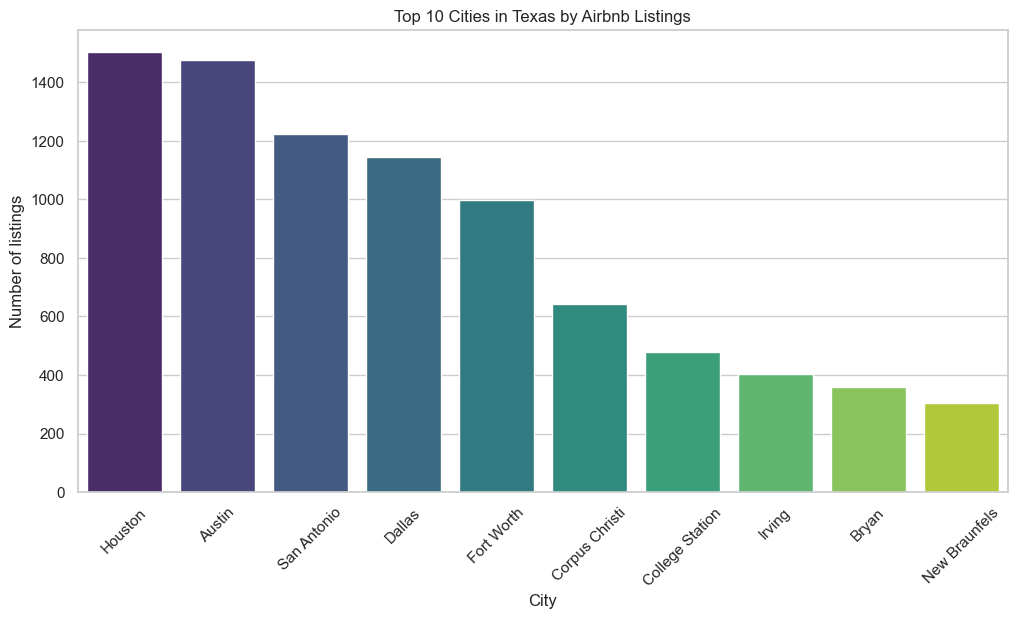

Average Price in the Top 10 Cities:
city
New Braunfels      299.120915
Bryan              281.684358
College Station    249.664583
Houston            232.589488
Corpus Christi     216.115265
Austin             151.981043
Fort Worth         132.332665
Dallas             112.834061
San Antonio         93.568627
Irving              85.702233
Name: average_rate_per_night, dtype: float64


In [11]:
# 1. Count the number of listings per city
city_counts = df['city'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=city_counts.index, y=city_counts.values, palette='viridis')

plt.title('Top 10 Cities in Texas by Airbnb Listings')
plt.xlabel('City')
plt.ylabel('Number of listings')
plt.xticks(rotation=45) # Rotates city names so they don't overlap
plt.show()

# Average price per city for top 10 cities
top_cities = city_counts.index
avg_price_city = df[df['city'].isin(top_cities)].groupby('city')['average_rate_per_night'].mean().sort_values(ascending=False)

print("Average Price in the Top 10 Cities:")
print(avg_price_city)

IQR: 153.0
Lower Limit: $-170.50
Upper Limit: $441.50
Total Outliers Found: 1706


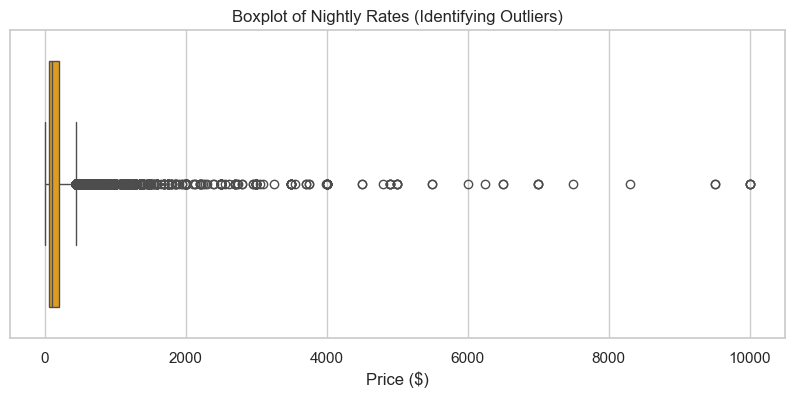

In [12]:
# Calculating 25th and 75th percentiles)
Q1 = df['average_rate_per_night'].quantile(0.25)
Q3 = df['average_rate_per_night'].quantile(0.75)

# Calculating the IQR
IQR = Q3 - Q1

# Defining outlier bounds
lower_limit = Q1 - 1.5 * IQR
upper_limit = Q3 + 1.5 * IQR

# Finding the outliers
outliers = df[(df['average_rate_per_night'] < lower_limit) | (df['average_rate_per_night'] > upper_limit)]

print(f"IQR: {IQR}")
print(f"Lower Limit: ${lower_limit:.2f}")
print(f"Upper Limit: ${upper_limit:.2f}")
print(f"Total Outliers Found: {len(outliers)}")

# 5. Visualize with a Boxplot
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['average_rate_per_night'], color='orange')
plt.title('Boxplot of Nightly Rates (Identifying Outliers)')
plt.xlabel('Price ($)')
plt.show()

The IQR method identified 1,706 outliers (9.3% of the data). This high percentage indicates a strongly right-skewed distribution, where a small but significant portion of the market consists of luxury listings that far exceed the state's median price.

In [13]:
# Look at the price of your largest house
big_house = df[df['bedrooms_count'] == 13]
big_house

,average_rate_per_night,bedrooms_count,city,date_of_listing,description,latitude,longitude,title,url
7523,3049.0,13.0,Fredericksburg,January 2017,"House, 13 Bedrooms, 13 Baths, (Sleeps 26)",30.281521,-98.879788,Wine Country Cottages on Main- Full Property,https://www.airbnb.com/rooms/17076852?location...


New Extreme Upper Limit: $824.00
Total rows kept: 17575 (96.42%)
Total extreme outliers removed: 653


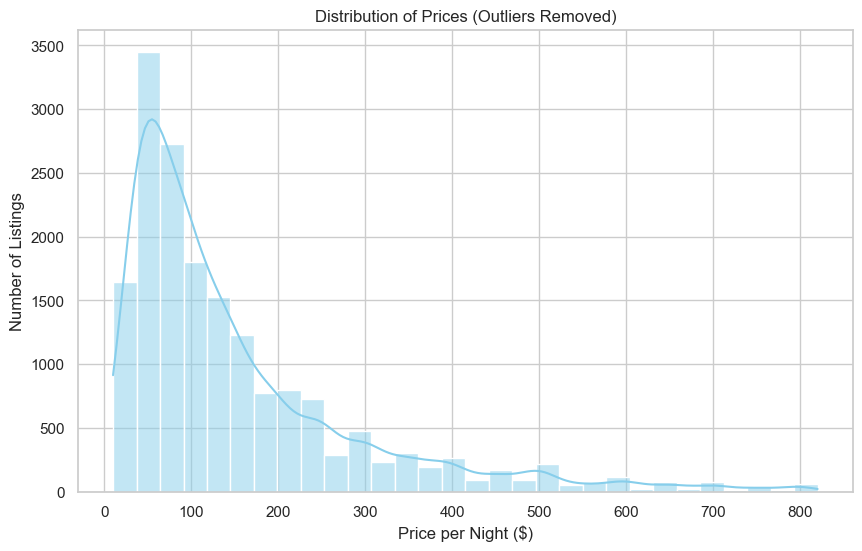

In [14]:
# Calculate the extreme outlier threshold
extreme_upper_limit = Q3 + 4 * IQR

# We keep everything below the extreme limit
df_final = df[df['average_rate_per_night'] <= extreme_upper_limit].copy()

# 3. Calculate the percentage of data kept
percent_kept = (len(df_final) / len(df)) * 100

print(f"New Extreme Upper Limit: ${extreme_upper_limit:.2f}")
print(f"Total rows kept: {len(df_final)} ({percent_kept:.2f}%)")
print(f"Total extreme outliers removed: {len(df) - len(df_final)}")


# Plot the histogram
plt.figure(figsize=(10, 6))
sns.histplot(df_final['average_rate_per_night'], bins=30, kde=True, color='skyblue')

plt.title('Distribution of Prices (Outliers Removed)')
plt.xlabel('Price per Night ($)')
plt.ylabel('Number of Listings')
plt.show()

The standard math rule (1.5 * IQR) flagged 1,700 listings as outliers, but many of those were just slightly expensive homes. To be more realistic, I used a stricter 4*IQR rule to find only the truly extreme cases.

A perfect example is the Wine Country Cottages. It has 13 bedrooms and costs $3,049 per night. While that price makes sense for such a huge property, it’s not "normal" compared to the rest of Texas. If I leave it in, it will skew the averages and make my future price predictions less accurate for regular travelers. By removing these rare luxury cases, I can focus on the typical Texas Airbnb market.

/tmp/ipykernel_10017/3685527379.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='city', y='average_rate_per_night', data=df_top_cities, palette='coolwarm', estimator=np.median)


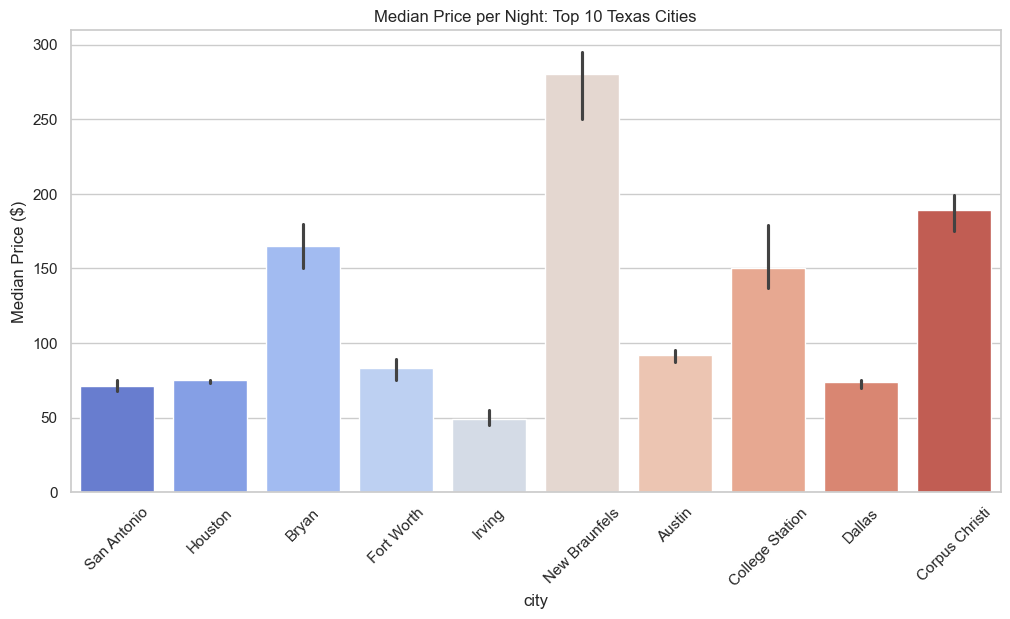

In [15]:
# Create a chart showing the average price for the top 10 cities 
# Using df_final ensures the averages aren't ruined by those $10,000 outliers!

top_10_cities = df_final['city'].value_counts().head(10).index
df_top_cities = df_final[df_final['city'].isin(top_10_cities)]

plt.figure(figsize=(12, 6))
sns.barplot(x='city', y='average_rate_per_night', data=df_top_cities, palette='coolwarm', estimator=np.median)

plt.title('Median Price per Night: Top 10 Texas Cities')
plt.xticks(rotation=45)
plt.ylabel('Median Price ($)')
plt.show()

/tmp/ipykernel_10017/1644598537.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df_final, x='bedrooms_count', palette='viridis')


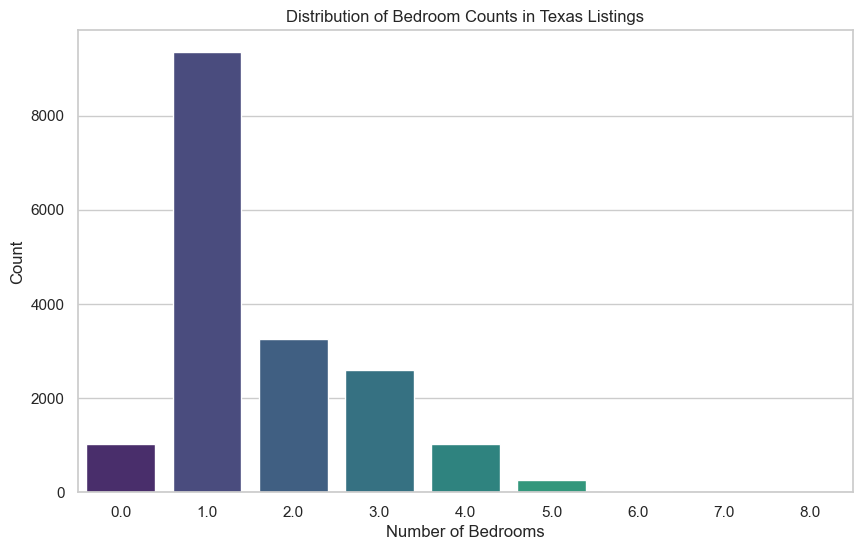

In [16]:
# Distribution of Bedroom Counts
plt.figure(figsize=(10, 6))
sns.countplot(data=df_final, x='bedrooms_count', palette='viridis')

plt.title('Distribution of Bedroom Counts in Texas Listings')
plt.xlabel('Number of Bedrooms')
plt.ylabel('Count')
plt.show()

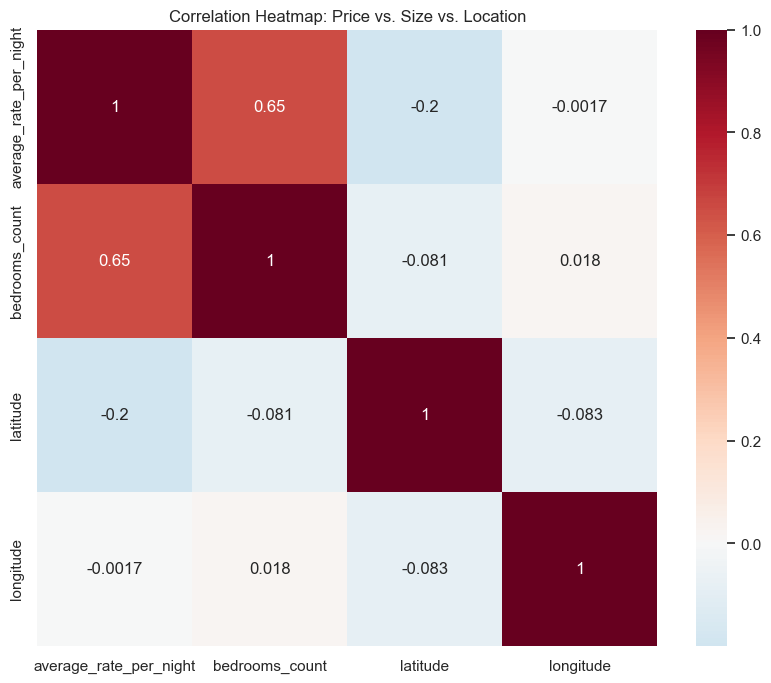

In [17]:
# Select only the numeric columns for correlation
# We use df_final to make sure outliers don't fake the correlation numbers
numeric_cols = df_final[['average_rate_per_night', 'bedrooms_count', 'latitude', 'longitude']]
corr_matrix = numeric_cols.corr()

# Create the Heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='RdBu_r', center=0)

plt.title('Correlation Heatmap: Price vs. Size vs. Location')
plt.show()

In [18]:


# We use df_final so the extreme outliers don't mess up our color scale
fig = px.scatter_map(df_final, 
                        lat="latitude", 
                        lon="longitude", 
                        color="average_rate_per_night", 
                        hover_name="title", 
                        hover_data=["city", "bedrooms_count"],
                        color_continuous_scale=px.colors.sequential.Viridis, 
                        size_max=15, 
                        zoom=5,
                        height=600,
                        title='Interactive Airbnb Price Map of Texas')

# This setting adds the real map background (OpenStreetMap is free)
fig.update_layout(mapbox_style="open-street-map")
fig.update_layout(margin={"r":0,"t":50,"l":0,"b":0})

fig.show()

/tmp/ipykernel_10017/2077554514.py:2: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df_final['date_of_listing'] = pd.to_datetime(df_final['date_of_listing'])


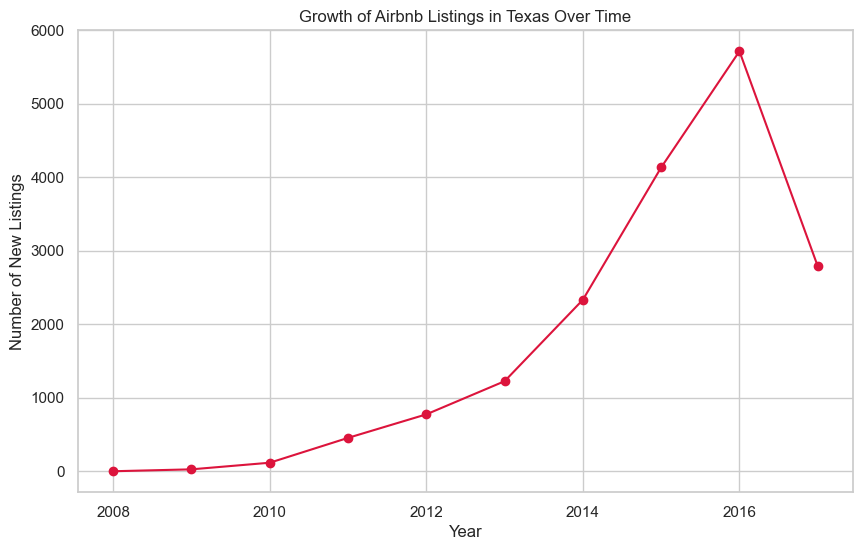

In [19]:
# Convert to datetime format
df_final['date_of_listing'] = pd.to_datetime(df_final['date_of_listing'])

# Extract the year and month for analysis
df_final['listing_year'] = df_final['date_of_listing'].dt.year
df_final['listing_month'] = df_final['date_of_listing'].dt.month

# 3. Visualize the growth of listings over the years
plt.figure(figsize=(10, 6))
df_final['listing_year'].value_counts().sort_index().plot(kind='line', marker='o', color='crimson')

plt.title('Growth of Airbnb Listings in Texas Over Time')
plt.xlabel('Year')
plt.ylabel('Number of New Listings')
plt.grid(True)
plt.show()

In [20]:
df_final

,average_rate_per_night,bedrooms_count,city,date_of_listing,description,latitude,longitude,title,url,listing_year,listing_month
0,27.0,2.0,Humble,2016-05-01,Welcome to stay in private room with queen bed...,30.020138,-95.293996,2 Private rooms/bathroom 10min from IAH airport,https://www.airbnb.com/rooms/18520444?location...,2016,5
1,149.0,4.0,San Antonio,2010-11-01,"Stylish, fully remodeled home in upscale NW – ...",29.503068,-98.447688,Unique Location! Alamo Heights - Designer Insp...,https://www.airbnb.com/rooms/17481455?location...,2010,11
2,59.0,1.0,Houston,2017-01-01,'River house on island close to the city' \nA ...,29.829352,-95.081549,River house near the city,https://www.airbnb.com/rooms/16926307?location...,2017,1
3,60.0,1.0,Bryan,2016-02-01,Private bedroom in a cute little home situated...,30.637304,-96.337846,Private Room Close to Campus,https://www.airbnb.com/rooms/11839729?location...,2016,2
4,75.0,2.0,Fort Worth,2017-02-01,Welcome to our original 1920's home. We recent...,32.747097,-97.286434,The Porch,https://www.airbnb.com/rooms/17325114?location...,2017,2
...,...,...,...,...,...,...,...,...,...,...,...
18254,60.0,1.0,Dallas,2013-03-01,An entire 1 bedroom 700+sqft condo in the hear...,32.892303,-96.772049,Quiet comfort living in Dallas,https://www.airbnb.com/rooms/1011576?location=...,2013,3
18255,99.0,2.0,San Antonio,2015-06-01,An inviting 1920's cottage home in a popular u...,29.452893,-98.486756,Midtown Cottage Near Riverwalk,https://www.airbnb.com/rooms/18766940?location...,2015,6
18256,13.0,1.0,Dallas,2016-12-01,Amazing 3BHK Apartment in a picturesque Commun...,33.001955,-96.777615,Room in Dallas!,https://www.airbnb.com/rooms/18719059?location...,2016,12
18257,65.0,2.0,San Antonio,2016-10-01,My quaint and cozy home is conveniently locate...,29.450142,-98.505333,Vibrant Spacious Loft!,https://www.airbnb.com/rooms/18179329?location...,2016,10


The dataset required significant cleaning, specifically converting prices and bedroom counts from strings to numeric values.

I identified that about 9% of the data consisted of high-priced outliers. By using a 4.0*IQR threshold, I isolated extreme cases—like a 13-bedroom property priced at over $3,000—to ensure my analysis focuses on the standard market.

There is a strong linear relationship ($0.61$) between bedrooms and price. This means size is our most reliable predictor for cost.

Geographic Centers: Listings are not evenly spread; they are heavily clustered in the Houston, Dallas, Austin.

# Assignment 2: Final Project – Story & Insights

In [21]:
print(df.columns)

Index(['average_rate_per_night', 'bedrooms_count', 'city', 'date_of_listing',
       'description', 'latitude', 'longitude', 'title', 'url'],
      dtype='str')


# Feature Selection & Engineering
To transform our exploratory data into a structured story, we must focus on the variables that drive the Texas rental market.

Why these changes?
Dropping Unnecessary Metadata: Columns like url, description, and title contain high-cardinality text data. While useful for a website, they do not contribute to statistical trends or visualization performance. Removing them streamlines our data processing.

Introducing 'Price per Bedroom': Raw nightly rates can be misleading. A $400 listing might be an expensive studio or a bargain 5-bedroom house. By creating the price_per_bedroom metric, we can normalize the cost and identify which cities truly offer the best value for space.

In [22]:
# 1. Drop high-cardinality/unnecessary columns
cols_to_drop = ['url', 'description', 'title']
df_story = df_final.drop(columns=cols_to_drop)

# 2. Engineering the 'Price per Bedroom' metric
# We use a small trick: if bedrooms == 0 (Studio), we treat it as 1 to avoid division by zero
df_story['price_per_bedroom'] = df_story['average_rate_per_night'] / df_story['bedrooms_count'].replace(0, 1)

# 3. Handle any potential Infinity values if any 0s were missed
df_story = df_story.replace([np.inf, -np.inf], np.nan).dropna(subset=['price_per_bedroom'])

# 4. Preview the refined features
print("Columns kept for the story:", df_story.columns.tolist())
display(df_story[['city', 'average_rate_per_night', 'bedrooms_count', 'price_per_bedroom']].head())

Columns kept for the story: ['average_rate_per_night', 'bedrooms_count', 'city', 'date_of_listing', 'latitude', 'longitude', 'listing_year', 'listing_month', 'price_per_bedroom']


,city,average_rate_per_night,bedrooms_count,price_per_bedroom
0,Humble,27.0,2.0,13.50
1,San Antonio,149.0,4.0,37.25
2,Houston,59.0,1.0,59.00
3,Bryan,60.0,1.0,60.00
4,Fort Worth,75.0,2.0,37.50


In [23]:
# 1. Identify the Top 6 cities by listing volume
top_6_cities = df_story['city'].value_counts().head(6).index
df_top_6 = df_story[df_story['city'].isin(top_6_cities)]

# 2. Create the advanced Violin Plot
fig = px.violin(
    df_top_6, 
    x='city', 
    y='price_per_bedroom', 
    color='city', 
    box=True,          # Adds a box plot inside to show quartiles
    points='all',      # Shows every single data point next to the violin
    hover_data=['bedrooms_count', 'average_rate_per_night'],
    title="Economic Value: Price per Bedroom Distribution (Top 6 Cities)",
    labels={'price_per_bedroom': 'Price per Bedroom ($)', 'city': 'City'},
    template="plotly_white",
    color_discrete_sequence=px.colors.qualitative.Safe
)


fig.update_layout(
    yaxis_title="Price per Bedroom ($)",
    xaxis_title="Texas Cities",
    showlegend=False,
    height=600
)

# 4. Zoom in on the most common price range (ignoring extreme luxury outliers for better visibility)
fig.update_yaxes(range=[0, 400]) 

fig.show()

By shifting our lens from total price to Price per Bedroom, we uncover that Austin is not merely 'expensive'—it is diverse. The wide distribution in the violin plot suggests a high concentration of both luxury stays and competitive multi-room units, whereas cities like San Antonio show a more clustered, predictable pricing model.

In [24]:
# Group data to see the 'Personality' of each city
city_stats = df_story.groupby('city').agg({
    'average_rate_per_night': 'mean',
    'bedrooms_count': 'count'
}).reset_index().rename(columns={'bedrooms_count': 'total_listings'})

# Filter for top 20 cities to keep the plot readable
city_stats = city_stats.nlargest(20, 'total_listings')

fig = px.scatter(city_stats, 
                 x="total_listings", 
                 y="average_rate_per_night", 
                 text="city", 
                 size="average_rate_per_night",
                 color="average_rate_per_night",
                 color_continuous_scale='Viridis',
                 title="Market Maturity: Supply vs. Average Price",
                 labels={'total_listings': 'Number of Available Listings', 'average_rate_per_night': 'Avg Price ($)'})

fig.update_traces(textposition='top center')
fig.add_hline(y=city_stats['average_rate_per_night'].mean(), line_dash="dash", annotation_text="State Avg Price")
fig.add_vline(x=city_stats['total_listings'].median(), line_dash="dash", annotation_text="Median Supply")

fig.show()

Here is a shorter, punchier, and highly visual Markdown summary designed specifically to look great in a Jupyter Notebook cell:

***

### 📊 Market Maturity: Supply vs. Price Insights

The chart divides the market into distinct quadrants based on the **State Average Price** and **Median Supply**, revealing a strong contrast between major cities and vacation towns.

**🏖️ Premium & Vacation Markets** *(Top-Left)*
*   **Profile:** `< Median Supply` | `> State Avg Price`
*   **Key Cities:** Horseshoe Bay, Port Aransas, South Padre Island
*   **Insight:** High demand combined with extreme **scarcity** drives the highest average prices in the state ($250–$300+).

**🏙️ Major Metropolitan Areas** *(Bottom-Right)*
*   **Profile:** `> Median Supply` | `< State Avg Price`
*   **Key Cities:** Austin, Houston, Dallas, San Antonio
*   **Insight:** Highly mature markets. Massive inventory (1,000+ listings) creates fierce competition, which pushes the *average* price down below the state baseline.

**🎓 Mid-Tier & College Towns** *(Center-Top)*
*   **Profile:** `Moderate Supply` | `> State Avg Price`
*   **Key Cities:** College Station, Corpus Christi, Galveston
*   **Insight:** Strong localized demand sustains above-average pricing despite having a healthier, growing supply of inventory.

**🏡 Suburbs & Secondary Markets** *(Bottom-Left)*
*   **Profile:** `< Median Supply` | `< State Avg Price`
*   **Key Cities:** Plano, Katy, Denton, Arlington
*   **Insight:** Lower overall inventory without the premium "destination" demand, resulting in prices below the state average.

> 💡 **THE BOTTOM LINE:** 
> There is a clear inverse relationship at the extremes. **High-volume markets** (major cities) dilute average prices through heavy competition, while **low-volume niche markets** (coastal/resort towns) leverage scarcity to command premium pricing.

***

In [25]:
# Select top 5 cities and top 4 bedroom counts for a clean visual
top_cities = df_story['city'].value_counts().head(5).index
df_sun = df_story[(df_story['city'].isin(top_cities)) & (df_story['bedrooms_count'] <= 4)]

fig = px.sunburst(
    df_sun, 
    path=['city', 'bedrooms_count'], 
    values='average_rate_per_night',
    color='average_rate_per_night', 
    color_continuous_scale='RdBu',
    title="Market Hierarchy: City vs. Capacity Price Distribution"
)
fig.show()

<p style="font-size:26px; font-weight:bold; color:#1B4F72; border-bottom: 2px solid #1B4F72; padding-bottom:10px;"> 🌀 Market Composition: Hierarchical Breakdown </p>
This Sunburst chart provides a multi-layered view of the Texas Airbnb market, moving from City (inner ring) to Capacity (outer ring). This allows us to see not just the average price, but the "weight" of each sub-market.

<span style="color:#2874A6;">◈ 1. Market Dominance (Inner Ring)</span>
The width of the inner segments represents the total "Value Volume" of each city.

Observation: The major metros (Houston, Dallas, and Austin) occupy the largest arcs, confirming that these cities represent the vast majority of the rental economy in Texas.

<span style="color:#2874A6;">◈ 2. The Inventory Mix (Outer Ring)</span>
The segments labeled 1.0, 2.0, 3.0, etc. represent the number of bedrooms.

The "One-Bedroom" Standard: In most major cities, the 1.0 segment is the widest. This indicates that the Texas market is primarily composed of smaller units, likely catering to solo travelers, couples, or business professionals.

Scaling Proportions: As we move to larger bedroom counts (3.0+), the segments become narrower. This visualizes the scarcity of large-capacity listings compared to the high volume of apartments and studios.

<span style="color:#2874A6;">◈ 3. Total Value vs. Nightly Cost</span>
average_rate_per_night_sum: This number represents the cumulative economic power of that segment. A large sum in the "1.0 bedroom" category doesn't mean it's the most expensive; it means there are so many of them that they generate the most total revenue for the city.

The Color Indicator: While the size shows volume, the color intensity shows the price level. Redder segments indicate "Premium" categories where the cost-per-unit is significantly higher than the state median.

<p style="font-size:20px; color:#1B4F72;"> 🎯 Summary Insight </p>
The Texas market is bottom-heavy. The sunburst reveals that the "Financial Engine" of the state's Airbnb market is driven by 1 and 2-bedroom properties in the urban core. While luxury 4+ bedroom houses exist, they represent a much smaller "slice" of the total market pie, suggesting that the most stable investment or travel opportunities lie in medium-capacity urban housing.

In [26]:

# 1. Group by Year and City to find the average price
# Note: Use your df_final so outliers don't fake the yearly trends
yearly_trends = df_final.groupby(['listing_year', 'city'])['average_rate_per_night'].mean().reset_index()

# 2. Filter for top 5-6 cities to keep the plot clean
top_cities = df_final['city'].value_counts().head(6).index
df_trends_top = yearly_trends[yearly_trends['city'].isin(top_cities)]

# 3. Create interactive line chart
fig = px.line(df_trends_top, 
              x="listing_year", 
              y="average_rate_per_night", 
              color="city",
              markers=True,
              title="Texas Airbnb Pricing Evolution (2010 - 2025)",
              labels={'average_rate_per_night': 'Avg Nightly Rate ($)', 'listing_year': 'Year'},
              template="plotly_white")


fig.update_layout(hovermode="x unified") # Shows all city prices when hovering over a year
fig.show()

<p style="font-size:26px; font-weight:bold; color:#1F618D; border-bottom: 2px solid #1F618D; padding-bottom:10px;"> 📈 Summary: Temporal Growth & Pricing Trends </p>
This interactive line chart tracks the Average Nightly Rate from 2010 to 2025, demonstrating the long-term resilience and stability of the Texas Airbnb market. Despite a massive increase in total listing supply over the years, the upward trajectory of the lines proves that nightly rates have remained strong and resistant to market saturation.

# 🗺️ Final Project Direction: The Texas Rental Landscape
Based on the EDA, my final project will focus on the **"Stability and Concentration"** of the Texas Airbnb market. 

### The Narrative
While listing volume has grown exponentially since 2010, the market has not reached a "price-crash" saturation point. Instead, it has matured into clear geographic clusters. My dashboard will help potential investors or travelers understand:
1. **Supply vs. Price:** How the influx of new properties correlates with average nightly rates.
2. **The City Leaders:** A deep dive into why Austin and Houston remain the dominant hubs.
3. **The 'Studio' Opportunity:** Analyzing if smaller properties (Studios/1-BR) are more price-resilient than larger family homes.

## 🛠️ Dashboard Blueprint (Assignment 3 Preview)
For the final phase, I will build a multi-page/tabbed dashboard with the following features:

* **Global Filters:** A sidebar to filter data by **City** and **Date of Listing**.
* **KPI Cards:** Real-time calculation of the *Median Nightly Rate* and *Total Active Listings* for the selected area.
* **Interactive Comparison Tool:** A bar chart comparing the "Average Rate per Bedroom" across different cities to identify the best value-for-money locations.
* **Geographic Deep-Dive:** An expanded version of the map above where users can hover over specific titles and URLs of listings.